In [1]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.inspection import permutation_importance

import matplotlib.pyplot as plt
import numpy as np

In [2]:
iris = load_iris()
X = iris.data
y = iris.target
feat_names = iris.feature_names
target_names = iris.target_names

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

In [4]:
rf = RandomForestClassifier(
    n_estimators=100,      # 树的数量
    max_features="sqrt",   # 每次分裂时随机选择的特征数
    oob_score=True,        # 启用 OOB 袋外估计
    random_state=42,
    n_jobs=-1              # 并行训练
)

rf.fit(X_train, y_train)

RandomForestClassifier(n_jobs=-1, oob_score=True, random_state=42)

In [5]:
y_pred = rf.predict(X_test)

print(f"OOB 准确率：{rf.oob_score_:.4f}")
print(f"测试集准确率：{accuracy_score(y_test, y_pred):.4f}")

OOB 准确率：0.9429
测试集准确率：1.0000


In [9]:
mdi_importances = rf.feature_importances_

In [6]:
perm_imp = permutation_importance(
    rf,
    X_test,
    y_test,
    n_repeats=30,
    random_state=42,
    n_jobs=-1
)

perm_importances = perm_imp.importances_mean

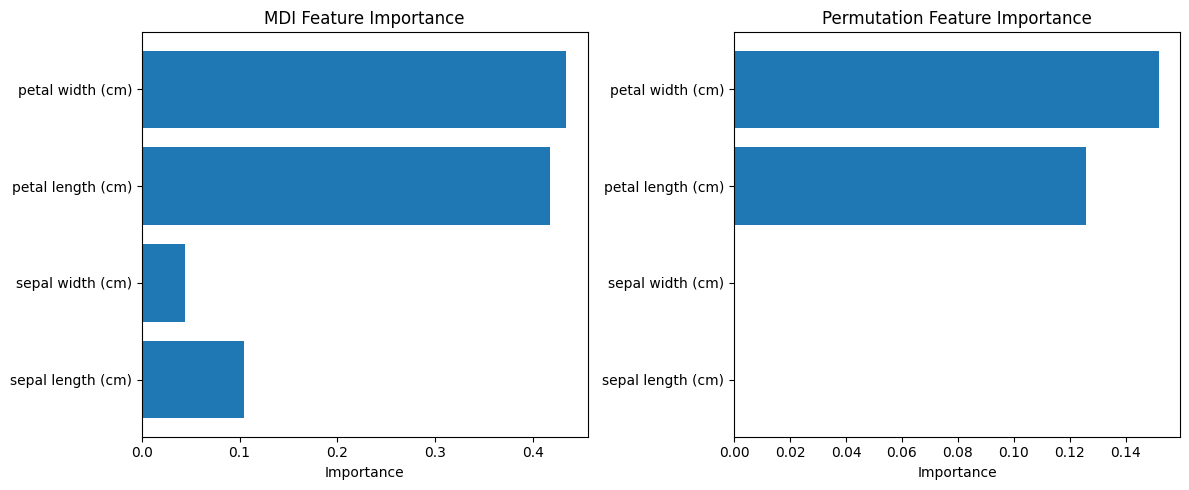

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# MDI 特征重要性
axes[0].barh(feat_names, mdi_importances)
axes[0].set_title("MDI Feature Importance")
axes[0].set_xlabel("Importance")

# Permutation 特征重要性
axes[1].barh(feat_names, perm_importances)
axes[1].set_title("Permutation Feature Importance")
axes[1].set_xlabel("Importance")

plt.tight_layout()
plt.show()